In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import os
import json
import shutil
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS
from matplotlib.lines import Line2D
from scipy.stats import linregress
import statsmodels.api as sm

from phd_project.config import config

from standes.analysis.recorders import get_recorder, get_recorders
from phd_project.scripts.templates.copy_templates_to_folders import (
    copy_structural_model, 
    configure_batch_run_file,
    )
from fitpo import fit_cbf_backbone
from fitpo.fitting import elastic_slope

cfg = config.load_config()

In [5]:
def _load_pushover_curve(building_folder: Path):
    # load a pushover curve
    po_folder = building_folder / "pushover"
    po_curve_file = po_folder / "po_curve.csv"

    poc = np.loadtxt(po_curve_file, delimiter=",")
    return poc

def _load_cyclic_pushover_curve(building_folder: Path):
    # load a pushover curve
    po_folder = building_folder / "cyclic_pushover"
    po_curve_file = po_folder / "po_curve.csv"

    poc = np.loadtxt(po_curve_file, delimiter=",")
    return poc

In [6]:
ROOT = cfg["analysis_data"]["dc2_sdof_fitting"]

In [7]:
# load the building dataset
with open(cfg["proc_data"]["dc2_casestudy_dataset"], "rb") as f:
    bdata_df = pickle.load(f)

bdata_df = bdata_df.set_index("name")
bdata_df = bdata_df.drop(columns="index")
bdata_df

buildings = bdata_df[bdata_df["n_storeys"] == 3].index
# buildings = bdata_df.index

pocs = {}

for b in buildings:
    pocs[b] = _load_pushover_curve(ROOT / b)

# 1. Original Backbone Curves

## 1.1 Fit Curves

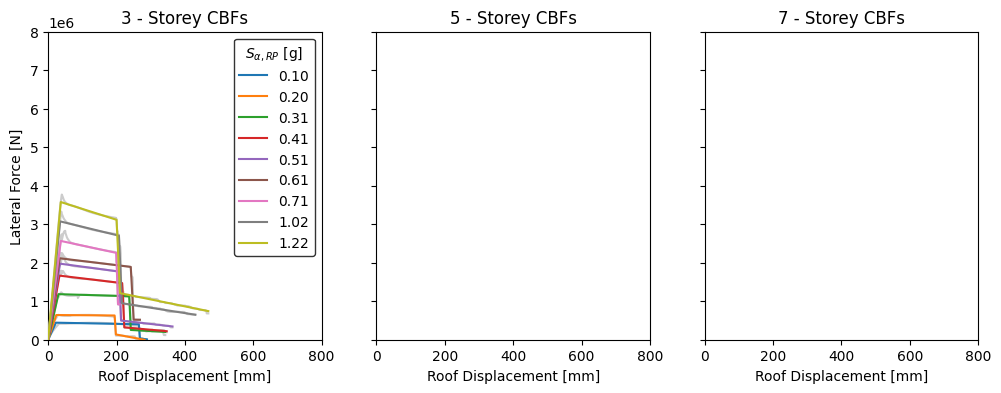

In [8]:
# Calculate the original backbone curves
bbs = {b: fit_cbf_backbone(poc, cusum_drift=0.3, cusum_threshold=4) for b, poc in pocs.items()}

colours = list(TABLEAU_COLORS.values())

fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(12, 4), sharey=True, sharex=True)
for ax, ns in zip([ax1, ax2, ax3], [3, 5, 7]):

    bs = bdata_df[bdata_df["n_storeys"] == ns].index
    for b, colour in zip(bs[:], colours):
        # plot the po curve
        try:
            poc = pocs[b]
            bb = bbs[b]
            sa = bdata_df.loc[b, "S_alpha_RP"]
            ax.plot(poc[:, 0], poc[:, 1], color="0.8", zorder=5)
            ax.plot(bb[:, 0], bb[:, 1], color=colour, label = f"{sa:.2f}", zorder=10)
        except KeyError:
            ...
   
    ax.set_xlabel("Roof Displacement [mm]")
    ax.set_title(f"{ns} - Storey CBFs")
ax1.set_ylabel("Lateral Force [N]")
ax1.set_xlim(0, 800)
ax1.set_ylim(0, 0.8e7)
legend = ax1.legend(title=r"$S_{\alpha, RP}$ [g]")
frame = legend.get_frame()
frame.set_edgecolor("black")

## 1.2 Clean up residual strength point and stiffness

All of the models that don't show a good residual branch will be assigned the average residual slope determined from the statistical analysis of the PO-Curves

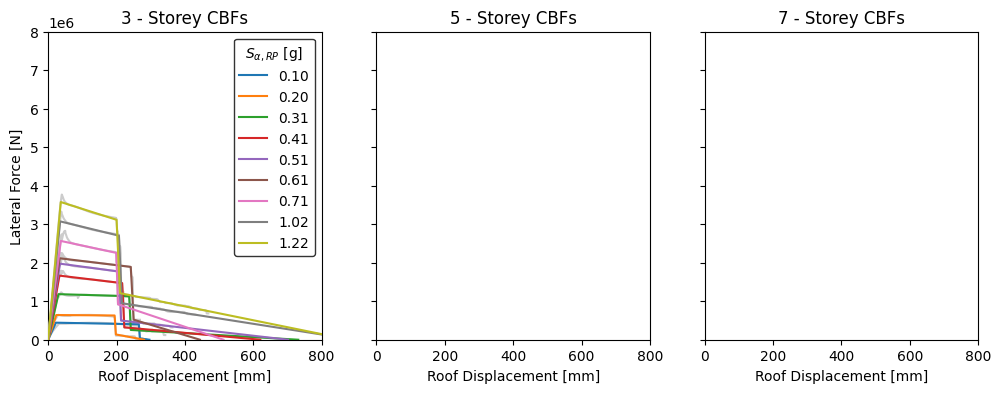

In [10]:
# models getting an artificial residual branch
gets_artifical_residual = [
    "3s_cbf_dc2_61",
    "3s_cbf_dc2_71",
    "5s_cbf_dc2_61",
    "5s_cbf_dc2_71",
    "5s_cbf_dc2_102",
    "7s_cbf_dc2_31",
    "7s_cbf_dc2_71",
    ]

kr_ke = -0.043     # assumed value based on statistical analysis of SDOF backbones. see wp1pt4pt1bb_simplified_po_curve_model.ipynb

for b in gets_artifical_residual:
    try:
        bb = bbs[b]
        ke = bb[1, 1] / bb[1, 0]
        kr = kr_ke * ke
        du = bb[3, 0] + abs(bb[3, 1] / kr)

        bb[-1, :] = [du, 0]
    except KeyError:
        ...


# extend the rest
for b in buildings:
    if b in gets_artifical_residual:
        continue
    
    bb = bbs[b]
    kr = (bb[4, 1] - bb[3, 1]) / (bb[4, 0] - bb[3, 0])
    du = bb[3, 0] + abs(bb[3, 1] / kr)
    bb[-1, :] = [du, 0]

# plot results
fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(12, 4), sharey=True, sharex=True)
for ax, ns in zip([ax1, ax2, ax3], [3, 5, 7]):

    bs = bdata_df[bdata_df["n_storeys"] == ns].index
    for b, colour in zip(bs[:], colours):
        # plot the po curve
        try:
            poc = pocs[b]
            bb = bbs[b]
            sa = bdata_df.loc[b, "S_alpha_RP"]
            ax.plot(poc[:, 0], poc[:, 1], color="0.8", zorder=5)
            ax.plot(bb[:, 0], bb[:, 1], color=colour, label = f"{sa:.2f}", zorder=10)
        except KeyError:
            ...
   
    ax.set_xlabel("Roof Displacement [mm]")
    ax.set_title(f"{ns} - Storey CBFs")
ax1.set_ylabel("Lateral Force [N]")
ax1.set_xlim(0, 800)
ax1.set_ylim(0, 0.8e7)
legend = ax1.legend(title=r"$S_{\alpha, RP}$ [g]")
frame = legend.get_frame()
frame.set_edgecolor("black")

## 1.3 Convert to Eq. SDOF

In [11]:
def _calculate_participation_factor(mass_matrix, modeshape_matrix, influence_matrix, node_info, dof):

    unconstrained_node_info = sorted([n for n in node_info if n[2] >= 0], key=lambda x: x[2])

    r1 = influence_matrix[:, 0]  # influence vector for the first mode
    idx_influence = np.where(r1 == 1)[0]  # indices of the dofs that have mass in the x direction

    # calculate the required parameters
    phi_1 = modeshape_matrix[:, 0] #/ np.max(Phi[:, 0])  # first mode shape

    aa = sorted([unconstrained_node_info[ii] for ii in idx_influence], key=lambda x: x[0]) # sort by node tag
    node_tags_used = np.reshape([a[0] for a in aa], (-1, 4), order="F")  # node tags for the dofs that have mass in the x direction, reshaped to have 4 columns (one for each column line)
    idxs = np.reshape([a[2] for a in aa], (-1, 4), order="F")  # indexes for the dofs that have mass in the x direction, reshaped to have 4 columns (one for each column line)

    phi = phi_1[idxs]#.mean(axis=1).reshape(-1, 1)
    norm_idx = np.abs(phi[-1, :]).argmax()
    normalisation_factor = phi[-1, norm_idx]
    phi /= normalisation_factor
    phi = phi.reshape(-1, 1)      # get it in a column vector

    m_vals = np.diagonal(mass_matrix)[idxs]
    m = np.zeros((len(phi), len(phi)))
    np.fill_diagonal(m, m_vals)     # get it in a diagonal matrix
    
    r = np.ones(phi.shape)

    generalised_mass = (phi.T @ m @ phi)[0, 0]      # modal mass
    m_star = (phi.T @ m @ r)[0, 0]     # from Fajfar (2000) and Baltzopoulos et al. 2018
    effective_mass = ((r.T @ m @ phi @ phi.T @ m @ r) / (phi.T @ m @ phi))[0, 0]    # participating mass
    Gamma = m_star / generalised_mass
    return Gamma, m, phi, node_tags_used, m_star, generalised_mass, effective_mass


def convert_poc_to_eq_sdof_poc(modal_results_folder, poc):
    # load mass matrix and the modeshapes
    with open(modal_results_folder / "modal_properties.json", "r") as file:
        modal_props = json.load(file)

    M = np.loadtxt(modal_results_folder / "mass_matrix.csv", delimiter=",")
    Phi = np.loadtxt(modal_results_folder / "mode_shapes.csv", delimiter=",")
    influence_matrix = np.loadtxt(modal_results_folder / "influence_matrix.csv", delimiter=",")
    node_info = json.load(open(modal_results_folder / "node_info.json", "r"))

    Gamma, m, phi, node_tags_used, m_star, generalised_mass, effective_mass = _calculate_participation_factor(M, Phi, influence_matrix, node_info, dof=1)

    eq_sdof_poc = poc / Gamma

    return eq_sdof_poc, Gamma, m_star, generalised_mass, effective_mass, modal_props["eigenPeriod"][0]


In [12]:
eq_sdof_pocs = {}
eq_sdof_bbs = {}
sdof_conv_data = {}
for b, poc in pocs.items():
    modal_results_folder = ROOT / b / "modal"
    sdof_poc, Gamma, m_star, generalised_mass, effective_mass, T1 = convert_poc_to_eq_sdof_poc(modal_results_folder, poc)
    eq_sdof_pocs[b] = sdof_poc
    print(f"Building: {b:15} : Particpation Factor: {Gamma:.3f}")
    sdof_conv_data[b] = {
        "gamma": Gamma,
        "m_star": m_star,
        "m_generalised": generalised_mass,
        "m_effective": effective_mass,
        "T1": T1 
    }

    eq_sdof_bbs[b] = bbs[b] / Gamma

Building: 3s_cbf_dc2_10   : Particpation Factor: 1.270
Building: 3s_cbf_dc2_20   : Particpation Factor: 1.277
Building: 3s_cbf_dc2_31   : Particpation Factor: 1.308
Building: 3s_cbf_dc2_41   : Particpation Factor: 1.315
Building: 3s_cbf_dc2_51   : Particpation Factor: 1.319
Building: 3s_cbf_dc2_61   : Particpation Factor: 1.313
Building: 3s_cbf_dc2_71   : Particpation Factor: 1.321
Building: 3s_cbf_dc2_102  : Particpation Factor: 1.312
Building: 3s_cbf_dc2_122  : Particpation Factor: 1.323


# 2. Soft Storey Stiffness

Make sure you have run the soft storey pushover and modal analyses

# 3. Spring Backbones

## 3.1 Backbone of Soft Storey Mechanism

In [13]:
# Load soft storey pushover curves
ss_pocs = {}
for b in buildings:
    ss_pocs[b] = _load_pushover_curve(ROOT / f"{b}_ss")

In [32]:
# Convert to to SDOF system
eq_sdof_pocs_ss = {}
# sdof_conv_data_ss = {}
for b, poc in ss_pocs.items():
    # modal_results_folder = ROOT / f"{b}_ss" / "modal"
    # sdof_poc, Gamma, m_star, generalised_mass, effective_mass, T1 = convert_poc_to_eq_sdof_poc(modal_results_folder, poc)
    # eq_sdof_pocs_ss[b] = sdof_poc
    gamma = sdof_conv_data[b]["gamma"]
    print(f"Building: {b:15} : Particpation Factor: {gamma:.3f}")
    # sdof_conv_data_ss[b] = {
    #     "gamma": Gamma,
    #     "m_star": m_star,
    #     "m_generalised": generalised_mass,
    #     "m_effective": effective_mass,
    #     "T1": T1 
    # }
    eq_sdof_pocs_ss[b] = poc / sdof_conv_data[b]["gamma"]

Building: 3s_cbf_dc2_10   : Particpation Factor: 1.270
Building: 3s_cbf_dc2_20   : Particpation Factor: 1.277
Building: 3s_cbf_dc2_31   : Particpation Factor: 1.308
Building: 3s_cbf_dc2_41   : Particpation Factor: 1.315
Building: 3s_cbf_dc2_51   : Particpation Factor: 1.319
Building: 3s_cbf_dc2_61   : Particpation Factor: 1.313
Building: 3s_cbf_dc2_71   : Particpation Factor: 1.321
Building: 3s_cbf_dc2_102  : Particpation Factor: 1.312
Building: 3s_cbf_dc2_122  : Particpation Factor: 1.323


Text(0.5, 0.98, 'Equivalent SDOF systems')

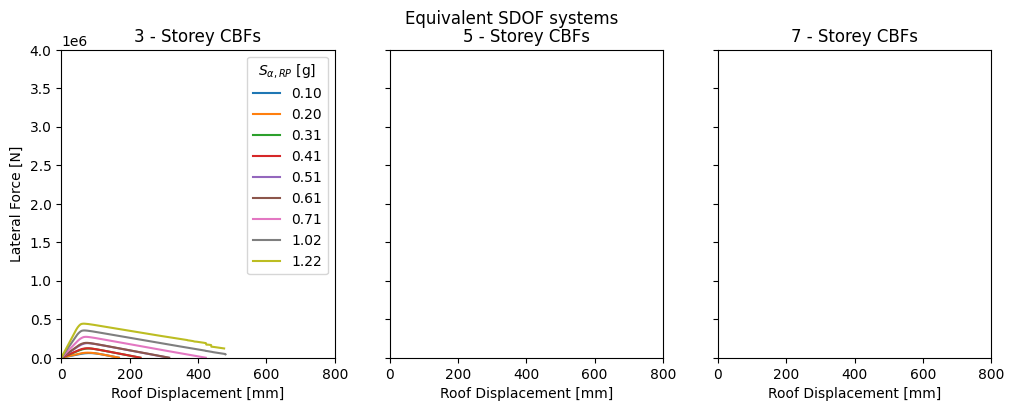

In [33]:
colours = list(TABLEAU_COLORS.values())

fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, ns in zip([ax1, ax2, ax3], [3, 5, 7]):
    bs = [b for b in buildings if bdata_df.loc[b, "n_storeys"] == ns]
    for b, colour in zip(bs[:], colours):

        # plot the po curve
        poc = eq_sdof_pocs_ss[b]
        sa = bdata_df.loc[b, "S_alpha_RP"]
        ax.plot(poc[:, 0], poc[:, 1], color=colour, label = f"{sa:.2f}")
    
    ax.set_ylim(0, 4e6)
    ax.set_xlim(0, 800)
    ax.set_xlabel("Roof Displacement [mm]")
    ax.set_title(f"{ns} - Storey CBFs")
ax1.set_ylabel("Lateral Force [N]")
ax1.legend(title=r"$S_{\alpha, RP}$ [g]")
plt.suptitle("Equivalent SDOF systems")



In [34]:
eq_sdof_k_init_ss = {}
for b, poc in eq_sdof_pocs_ss.items():
    idx_max = np.argmax(poc[:, 1])
    f_peak = poc[idx_max, 1]
    eq_sdof_k_init_ss[b] = elastic_slope(poc[:idx_max+1, 0], poc[:idx_max+1, 1], f_peak)

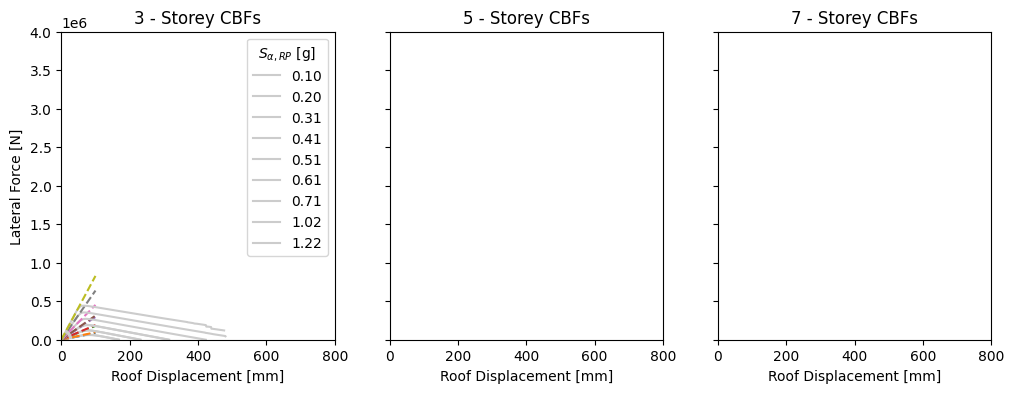

In [35]:
xs = np.linspace(0, 100)

colours = list(TABLEAU_COLORS.values())

fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, ns in zip([ax1, ax2, ax3], [3, 5, 7]):
    bs = [b for b in buildings if bdata_df.loc[b, "n_storeys"] == ns]
    for b, colour in zip(bs[:], colours):

        ky = xs * eq_sdof_k_init_ss[b]

        # plot the po curve
        poc = eq_sdof_pocs_ss[b]
        sa = bdata_df.loc[b, "S_alpha_RP"]
        ax.plot(poc[:, 0], poc[:, 1], color="0.8", label = f"{sa:.2f}")
        ax.plot(xs, ky, color=colour, ls = "--")
    
    ax.set_ylim(0, 4e6)
    ax.set_xlim(0, 800)
    ax.set_xlabel("Roof Displacement [mm]")
    ax.set_title(f"{ns} - Storey CBFs")
ax1.set_ylabel("Lateral Force [N]")
ax1.legend(title=r"$S_{\alpha, RP}$ [g]")



Now we combine this stiffness with the residual strength branch of the whole system

In [36]:
# the maximum force of the ss spring is the residual strength after fracture of the system.
eq_sdof_bbs_ss = {}

for b, bb in eq_sdof_bbs.items():

    fr = bb[-2, 1]
    dr = bb[-2, 0]
    fy_ss = fr
    dy_ss = fy_ss / eq_sdof_k_init_ss[b]

    if dy_ss > dr:
        dy_ss = dr

    eq_sdof_bbs_ss[b] = np.array([
        [0, 0], 
        [dy_ss, fy_ss],
        bb[-2, :],
        bb[-1, :]])

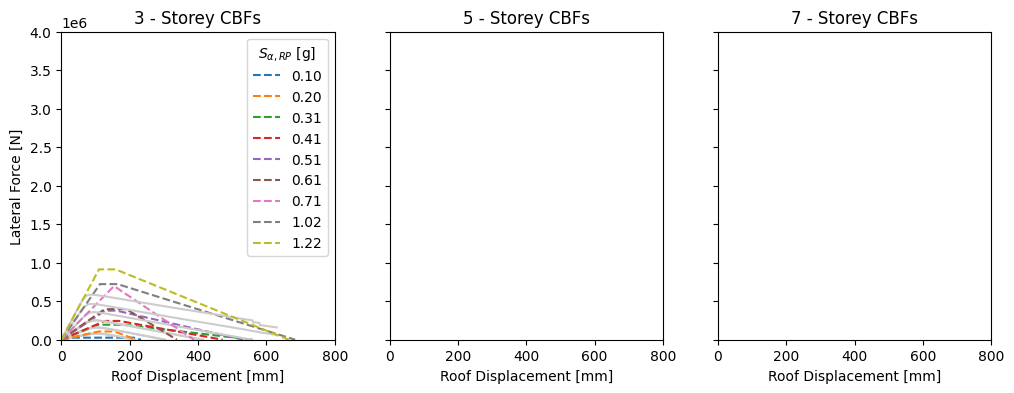

In [37]:
colours = list(TABLEAU_COLORS.values())

fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, ns in zip([ax1, ax2, ax3], [3, 5, 7]):
    bs = [b for b in buildings if bdata_df.loc[b, "n_storeys"] == ns]
    for b, colour in zip(bs[:], colours):

        bb = eq_sdof_bbs_ss[b]

        # plot the po curve
        poc = ss_pocs[b]
        sa = bdata_df.loc[b, "S_alpha_RP"]
        ax.plot(poc[:, 0], poc[:, 1], color="0.8", )
        ax.plot(bb[:, 0], bb[:, 1], color=colour, ls = "--", label = f"{sa:.2f}")
    
    ax.set_ylim(0, 4e6)
    ax.set_xlim(0, 800)
    ax.set_xlabel("Roof Displacement [mm]")
    ax.set_title(f"{ns} - Storey CBFs")
ax1.set_ylabel("Lateral Force [N]")
ax1.legend(title=r"$S_{\alpha, RP}$ [g]")

## 3.2 Backbone of Braces

The backbone of the spring representing the braces is simply the difference between the total system and the idealised mechanism system (Soft-Storey)

In [38]:
def get_poc_diff(curve1, curve2):
    """
    Calculates the exact difference between two piecewise linear pushover curves
    by harmonizing x-values using the union of all breakpoints.
    diff = curve1 - curve2
    """
    x1, y1 = curve1[:, 0], curve1[:, 1]
    x2, y2 = curve2[:, 0], curve2[:, 1]

    # Define the boundaries of the overlapping region
    x_start = max(x1.min(), x2.min())
    x_end = min(x1.max(), x2.max())

    if x_start > x_end:
        raise ValueError("Curves do not overlap.")

    # Combine all x-coordinates from both curves
    all_x = np.concatenate([x1, x2])
    
    # Filter for points within overlap and keep unique, sorted values
    common_x = np.unique(all_x[(all_x >= x_start) & (all_x <= x_end)])

    # Interpolate both curves onto the exact breakpoint grid
    y1_interp = np.interp(common_x, x1, y1)
    y2_interp = np.interp(common_x, x2, y2)

    # Difference reflects exact change between piecewise segments
    difference = y1_interp - y2_interp

    return np.column_stack((common_x, difference)), np.column_stack((common_x, y2_interp))

3s_cbf_dc2_122


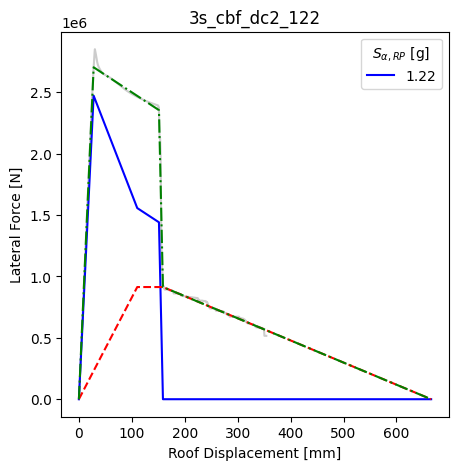

In [49]:
eq_sdof_bbs_br = {}
bbs_ss_common_x = {}
for b, bb in eq_sdof_bbs.items():
    try:
        bb_ss = eq_sdof_bbs_ss[b]
        eq_sdof_bbs_br[b], bbs_ss_common_x[b] = get_poc_diff(bb, bb_ss)
    except KeyError:
        ...

fig, ax1 = plt.subplots(figsize=(5, 5))
idx = 8
for b in buildings[idx:idx+1]:
    print(b)
    poc = eq_sdof_pocs[b]
    bb_br = eq_sdof_bbs_br[b]
    bb_ss = bbs_ss_common_x[b]
    bb_tot = np.column_stack([bb_br[:, 0], (bb_br[:, 1] + bb_ss[:, 1])])
    # plot the po curve
    sa = bdata_df.loc[b, "S_alpha_RP"]
    ax1.plot(poc[:, 0], poc[:, 1], color="0.8")
    ax1.plot(bb_br[:, 0], bb_br[:, 1], color="b", ls = "-", label = f"{sa:.2f}")
    ax1.plot(bb_ss[:, 0], bb_ss[:, 1], color="r", ls = "--")
    ax1.plot(bb_tot[:, 0], bb_tot[:, 1], color="g", ls = "-.")

    # ax.set_ylim(0, 4e6)
    # ax.set_xlim(0, 800)
    ax1.set_xlabel("Roof Displacement [mm]")
    ax1.set_title(f"{b}")
ax1.set_ylabel("Lateral Force [N]")
ax1.legend(title=r"$S_{\alpha, RP}$ [g]")

# 4. Save Backbones

In [22]:
folder = cfg["proc_data"]["sdof_parameters"]

for b in buildings:
    bb_braces = eq_sdof_bbs_br[b].tolist()[:-1]
    bb_frame = eq_sdof_bbs_ss[b].tolist()

    data = {
        "backbone_braces": bb_braces,
        "backbone_frame": bb_frame,
        "sdof_conv_data": sdof_conv_data[b],
        }

    filename = f"{b}_sdof_parameters.json"
    with open(folder / filename, "w") as file:
        json.dump(data, file, indent=4)



# 5. Alternative Option

We want SDOF systems that have a suitable cyclic response. At this stage I am not too worried about the static pushover response. Instead I think we should focus on calibrating the spring backbones based on what we observe in a cyclic pushover response rather than the static pushover

## 5.1 Load and compare 3s cyclic pushover curves

In [23]:
def cumulative_distance(d):
    """
    Calculates cumulative absolute displacement.
    i.e. the total distance the roof node travelled
    """
    return np.concatenate(([0], np.cumsum(np.abs(np.diff(d)))))

In [24]:
cpocs = {}

for b in buildings:
    if bdata_df.loc[b, "n_storeys"] == 3:
        cpocs[b] = _load_cyclic_pushover_curve(ROOT / b)

3s_cbf_dc2_10 total distance: 6876.42
3s_cbf_dc2_20 total distance: 6876.41
3s_cbf_dc2_31 total distance: 6876.41
3s_cbf_dc2_41 total distance: 6876.40
3s_cbf_dc2_51 total distance: 6876.40
3s_cbf_dc2_61 total distance: 4190.14
3s_cbf_dc2_71 total distance: 4118.57
3s_cbf_dc2_102 total distance: 6876.43
3s_cbf_dc2_122 total distance: 2800.69


(-300.0, 300.0)

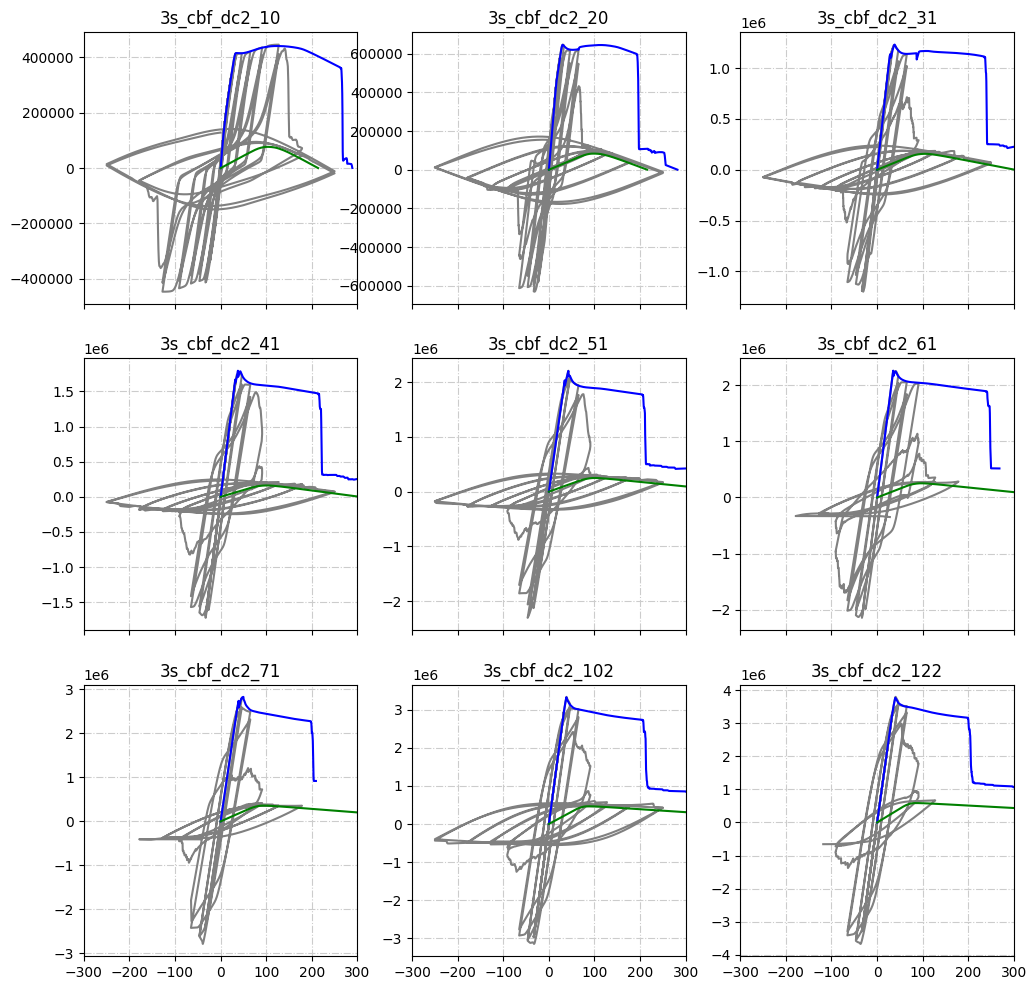

In [25]:
total_n = len(cpocs)
n_rows = int(round(total_n / 3, 0))
n_cols = 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*4, ), sharex=True)


for (b, cpoc), ax in zip(cpocs.items(), axs.flatten()):
    
    poc = pocs[b]
    poc_ss = ss_pocs[b]
    ax.plot(cpoc[:, 0], cpoc[:, 1], color="0.5")
    ax.plot(poc[:, 0], poc[:, 1], color="b")
    ax.plot(poc_ss[:, 0], poc_ss[:, 1], color="g")

    ax.set_title(b)
    ax.grid(ls="-.", color="0.8")
    
    print(b, f"total distance: {cumulative_distance(cpoc[:, 0])[-1]:.2f}" )

ax.set_xlim(-300, 300)